Dataset Shape: (7043, 33)
   CustomerID  Count        Country       State         City  ZipCode  \
0  3668-QPYBK      1  United States  California  Los Angeles    90003   
1  9237-HQITU      1  United States  California  Los Angeles    90005   
2  9305-CDSKC      1  United States  California  Los Angeles    90006   
3  7892-POOKP      1  United States  California  Los Angeles    90010   
4  0280-XJGEX      1  United States  California  Los Angeles    90015   

                  LatLong   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  PaperlessBilling              PaymentMethod  M

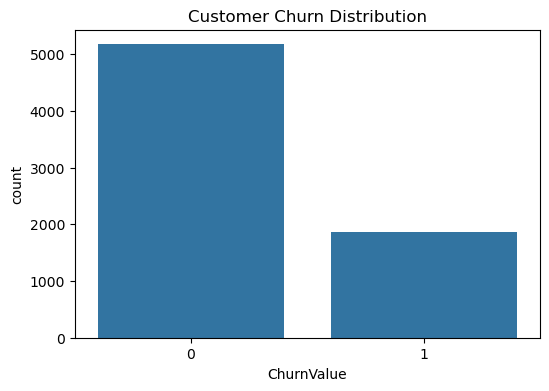

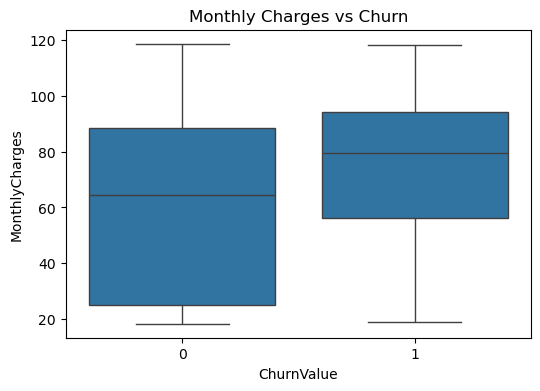

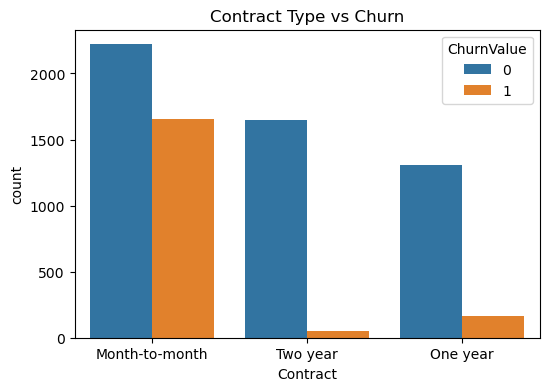

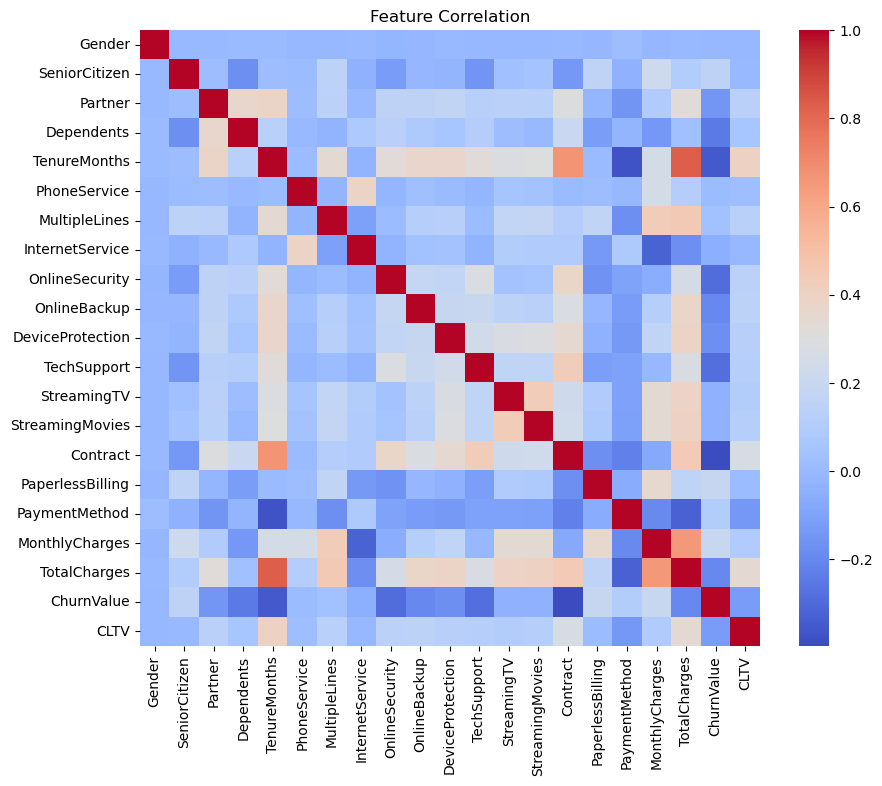

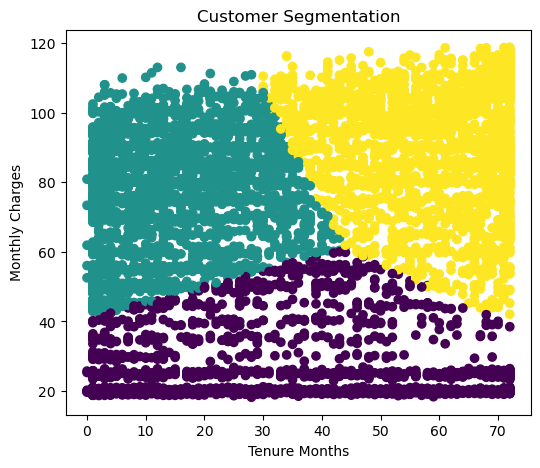


Logistic Regression Accuracy: 0.7991483321504613
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1009
           1       0.67      0.57      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.79      0.80      0.79      1409


Random Forest Accuracy: 0.8048261178140526
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1009
           1       0.70      0.55      0.62       400

    accuracy                           0.80      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



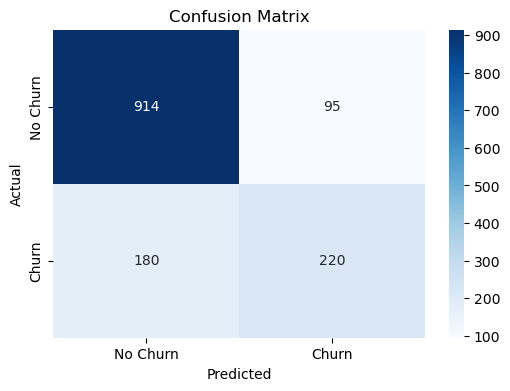


ROC-AUC Score: 0.8502886521308227


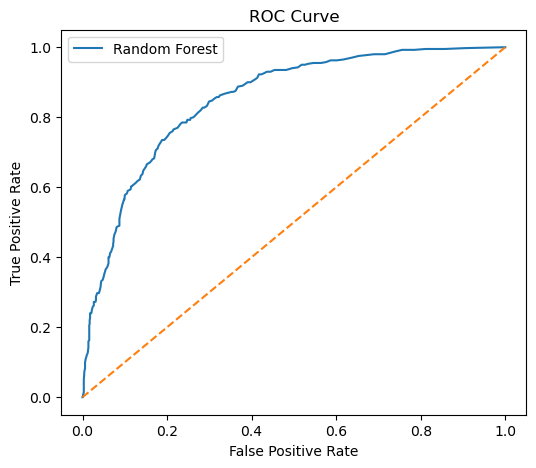


Cross Validation Scores: [0.78566359 0.80340667 0.77643719 0.81321023 0.80610795]
Average Accuracy: 0.7969651267823731


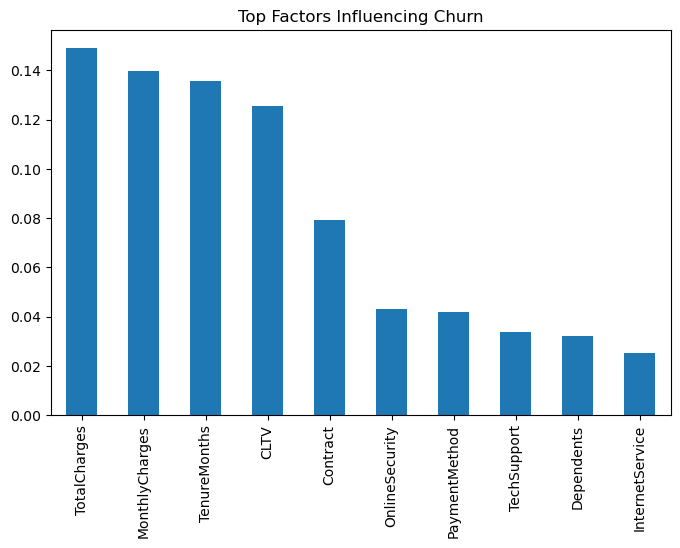


Predicted Churn: [1]
Churn Probability: [[0.285 0.715]]
Model saved successfully


In [21]:
# =========================================
# TELECOM CHURN ANALYSIS PIPELINE
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve


# =========================================
# LOAD DATA
# =========================================

file_path = r"C:\Users\lenovo\Downloads\archive (6)\Telco_customer_churn.xlsx"   # File Saved in system , Dataset is provided

df = pd.read_excel(file_path)

print("Dataset Shape:", df.shape)

# Remove spaces in column names
df.columns = df.columns.str.replace(" ", "")

print(df.head())


# =========================================
# DROP IRRELEVANT COLUMNS
# =========================================

drop_cols = [
    "CustomerID","Count","Country","State","City",
    "ZipCode","LatLong","Latitude","Longitude",
    "ChurnLabel","ChurnScore","ChurnReason"
]

df.drop(columns=drop_cols, inplace=True, errors="ignore")


# =========================================
# DATA CLEANING
# =========================================

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())


# =========================================
# EXPLORATORY DATA ANALYSIS
# =========================================

plt.figure(figsize=(6,4))
sns.countplot(x="ChurnValue", data=df)
plt.title("Customer Churn Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="ChurnValue", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Contract", hue="ChurnValue", data=df)
plt.title("Contract Type vs Churn")
plt.show()


# =========================================
# ENCODE CATEGORICAL VARIABLES
# =========================================

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])


# =========================================
# CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()


# =========================================
# CUSTOMER SEGMENTATION (KMEANS)
# =========================================

cluster_features = df[["TenureMonths","MonthlyCharges","TotalCharges"]]

scaler_cluster = StandardScaler()

scaled_data = scaler_cluster.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)

df["Cluster"] = kmeans.fit_predict(scaled_data)

plt.figure(figsize=(6,5))
plt.scatter(
    df["TenureMonths"],
    df["MonthlyCharges"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Tenure Months")
plt.ylabel("Monthly Charges")
plt.title("Customer Segmentation")
plt.show()


# =========================================
# CHURN PREDICTION
# =========================================

X = df.drop("ChurnValue", axis=1)

y = df["ChurnValue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# =========================================
# SCALE DATA (FOR LOGISTIC REGRESSION)
# =========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# =========================================
# LOGISTIC REGRESSION
# =========================================

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, log_pred))

print(classification_report(y_test, log_pred))


# =========================================
# RANDOM FOREST
# =========================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))


# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# =========================================
# MODEL PERFORMANCE METRICS
# =========================================

rf_probs = rf_model.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, rf_probs)

print("\nROC-AUC Score:", roc_score)

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


# =========================================
# CROSS VALIDATION
# =========================================

scores = cross_val_score(rf_model, X, y, cv=5)

print("\nCross Validation Scores:", scores)

print("Average Accuracy:", np.mean(scores))


# =========================================
# FEATURE IMPORTANCE
# =========================================

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Top Factors Influencing Churn")

plt.show()


# =========================================
# FUTURE CHURN PREDICTION
# =========================================

sample_customer = X.iloc[[10]]

prediction = rf_model.predict(sample_customer)

probability = rf_model.predict_proba(sample_customer)

print("\nPredicted Churn:", prediction)

print("Churn Probability:", probability)

import pickle

with open("churn_model.pkl","wb") as f:
    pickle.dump(rf_model,f)

print("Model saved successfully")